In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
ratings = pd.read_csv("../data/01_raw/ratings.csv")
movies = pd.read_csv("../data/01_raw/movies.csv")

In [7]:
print(f"Ratings: {ratings.shape[0]:,} rows")
print(f"Movies: {movies.shape[0]:,} rows\n")

Ratings: 25,000,095 rows
Movies: 62,423 rows


In [10]:
num_users = ratings['userId'].nunique()
num_movies_rated = ratings['movieId'].nunique()
total_possible_interactions = num_users * num_movies_rated
actual_interactions = len(ratings)
sparsity = 1 - (actual_interactions / total_possible_interactions)

print(f"Unique Users: {num_users:,}")
print(f"Unique Movies Rated: {num_movies_rated:,}")
print(f"Sparsity: {sparsity:.4%}")

Unique Users: 162,541
Unique Movies Rated: 59,047
Sparsity: 99.7395%


C:\Users\Michal\AppData\Local\Temp\ipykernel_34800\2076452631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ratings, x='rating', palette='viridis')


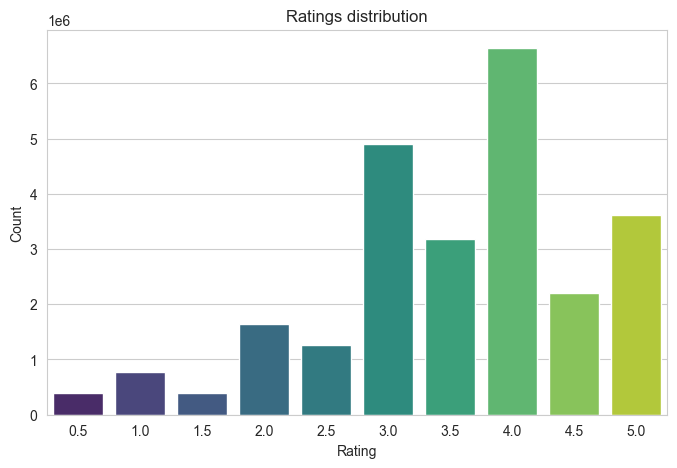

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=ratings, x='rating', palette='viridis')
plt.title('Ratings distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

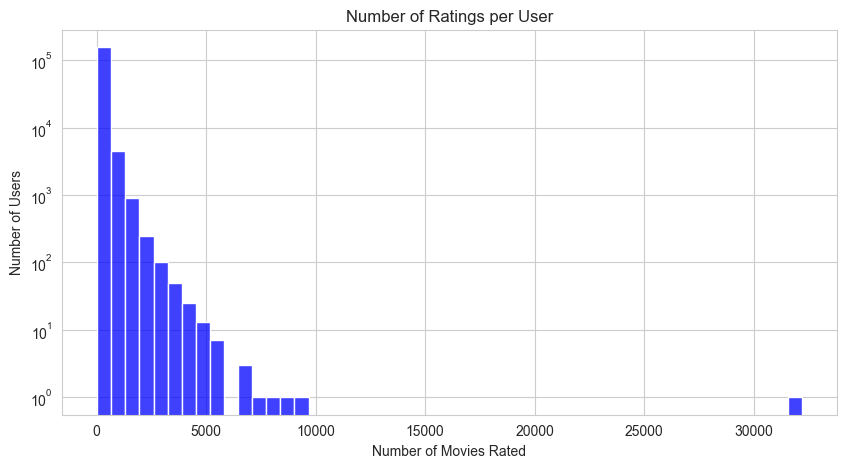

In [12]:
user_activity = ratings.groupby('userId').size()

plt.figure(figsize=(10, 5))
sns.histplot(user_activity, bins=50, kde=False, color='blue')
plt.title('Number of Ratings per User')
plt.xlabel('Number of Movies Rated')
plt.ylabel('Number of Users')
plt.yscale('log') # Log scale because recommender data is usually heavily skewed
plt.show()

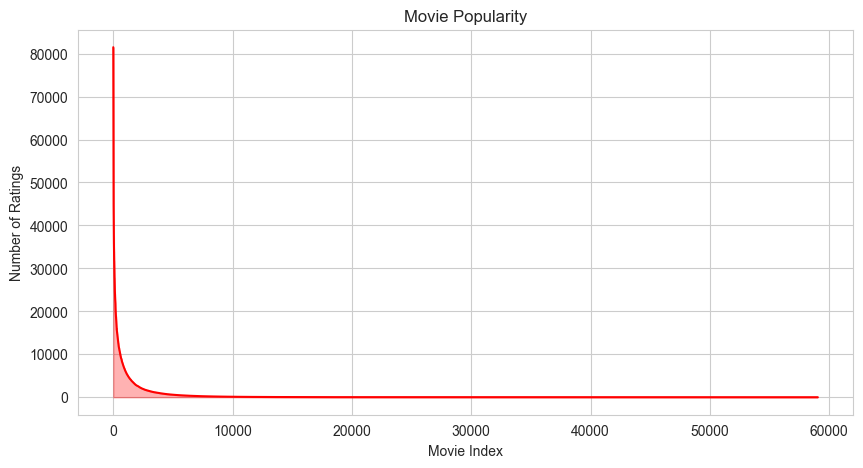

In [20]:
movie_popularity = ratings.groupby('movieId').size().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
plt.plot(movie_popularity.values, color='red')
plt.title('Movie Popularity')
plt.xlabel('Movie Index')
plt.ylabel('Number of Ratings')
plt.fill_between(range(len(movie_popularity)), movie_popularity.values, color='red', alpha=0.3)
plt.show()

In [19]:
top_movies = ratings.groupby('movieId').size().reset_index(name='rating_count')
top_movies = top_movies.merge(movies, on='movieId').sort_values(by='rating_count', ascending=False)
print(top_movies[['title', 'rating_count']].head(5))

                                 title  rating_count
351                Forrest Gump (1994)         81491
314   Shawshank Redemption, The (1994)         81482
292                Pulp Fiction (1994)         79672
585   Silence of the Lambs, The (1991)         74127
2480                Matrix, The (1999)         72674
